# Record fixes and openness robustness tests — `eval.py` demo

**Artifact:** `art_oKOd21ZMnu9S` (iteration 4, evaluation 3). It is an exploratory boundary study plus a pack of corrections to the record. No new data was collected and no LLM was called.

The full pipeline has several stages. `partb_core.py` runs Gate T0, B1 and B2, `spec_curve.py` runs B3, `heterogeneity.py` runs B4, and `step3_drca.py`, `build_corrections.py` and `verify_ledger.py` follow. Each stage writes result files to `results/`. **`eval.py` is the last step (STEP 6).** It estimates nothing new. It reads those result files and assembles `eval_out.json` in the `exp_eval_sol_out` schema, which has two parts:

* **`metrics_agg`** has about 100 headline numbers:
  * Gate T0 reproduction of Exp8.
  * B1: how much of the breadth effect (`M0_density_end`, `D_vol_end`) comes from the pre-onset footprint.
  * B2: pooled partial Spearman of the OPEN composite on held-out units.
  * B3: the 1,920-spec curve and its Freedman–Lane null.
  * B4: I², the meta-regression and the LIFEENV diagnosis.
  * STEP 3: the D_rca comparison.
  * Status counts for the claims ledger.
* **Three datasets**, each with one example per row:
  * `open_heldout_concepts`: held-out concepts, with OPEN / OPEN_PC1 used as predictions of the outcome `O2r_m50`.
  * `spec_curve`: one row per specification.
  * `claims_ledger_v3`: one row per claim, comparing the reported value with the value in the file.

**What this notebook does.** It runs the original `eval.py` code, split into cells. The input is `mini_demo_data.json`, a small bundle that contains:
* the small `results/*` files, verbatim;
* slices of at most 100 rows from the three row-level tables. The full tables have 7,728, 1,920 and 1,290 rows.

The bundle is written to a local `results/` folder, so the original functions run with only minimal path changes. At the end, the recomputed metrics are compared with the numbers from the original full run.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, pyarrow (parquet), matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'pyarrow==18.1.0', 'matplotlib==3.10.0')

## Imports
This is the original import block of `eval.py`, which pins BLAS to one thread before numpy loads. The original also has `sys.path.insert(... "lib")` and `from common import ...`. Those lines are replaced by a few constants copied from `lib/common.py` in the setup cell below. `hashlib` is needed for `sha256`, and `matplotlib` is added for the final plots.

In [2]:
from __future__ import annotations

import os as _os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    _os.environ[_v] = "1"

import json
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger

# notebook additions
import hashlib
import matplotlib.pyplot as plt

## Load the demo data
The notebook tries the GitHub raw URL first, so it works in Colab. If that fails, it uses a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_MjdbXJqg-rPl/round-4/evaluation-3/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["about"])
print("results files:", list(data["results_files"]))
print("table slices :", {k: len(v) for k, v in data["tables"].items()})
print("full sizes   :", data["table_full_sizes"])

Mini input bundle for the demo of eval.py (iteration 4, evaluation 3). 'results_files' are the small results/* files verbatim (raw text). 'tables' are <=100-row slices of the three row-level tables that eval.py turns into datasets (b_table.parquet held-out concepts, spec_curve_specs.csv, claims_ledger_v3.csv), plus the status column of the iteration-3 Eval2 ledger. 'reference_full_run' holds metrics_agg and dataset sizes from the original full run for comparison.
results files: ['gate_T0.json', 'post_onset_rescore.json', 'spec_curve.json', 'heterogeneity.json', 'drca_persist_comparison.json', 'ledger_verification.json', 'boundary_spec.json', 'per_group_pooled.csv']
table slices : {'b_table': 100, 'spec_curve_specs': 100, 'claims_ledger_v3': 100, 'eval2_claims_ledger': 246}
full sizes   : {'b_table_heldout6': 7728, 'spec_curve_specs': 1920, 'claims_ledger_v3': 1290}


## Config
`eval.py` has no iterations, epochs or sampling. The only thing that can be tuned is **how many rows of each row-level table** get written into the demo `results/` folder. The bundle holds at most 100 rows per table, while the original run used every row.

* `N_CONCEPTS` is the number of held-out concepts, drawn from the 6 held-out units. Rows are taken round-robin across units. Rank percentiles are computed *within unit*, so they depend on how many rows each unit has.
* `N_SPECS` is the number of rows kept from the specification curve.
* `N_LEDGER` is the number of rows kept from claims ledger v3. The ledger's status counts in `metrics_agg` are computed from this slice.

In [5]:
# Demo values (bundle max = 100 each). Original full run: all rows -> N_CONCEPTS = 7728, N_SPECS = 1920, N_LEDGER = 1290
N_CONCEPTS = 100
N_SPECS = 100
N_LEDGER = 100

## Setup: constants from `lib/common.py` and a local `results/` folder
`eval.py` imports `LOGS, RES, SEED, UNITS6, WS, sha256` from `lib/common.py`. Here those names are defined with the same values as in `common.py`, and `sha256` is copied verbatim. `WS` is a local demo folder instead of the artifact workspace.

The bundle is then written into `WS/results/`:
* The small JSON/CSV result files are written as raw text. This keeps `sha256(boundary_spec.json)` identical to the sealed spec.
* The three tables are sliced according to the config and written in their original formats (parquet or CSV).
* The iteration-3 Eval2 ledger is written to `WS/results/eval2_claims_ledger.csv`. The original read it from a sibling workspace.

In [6]:
# --- from lib/common.py (same values) ---
WS = Path("demo_eval_ws").resolve()
RES = WS / "results"
LOGS = WS / "logs"
for _d in (RES, LOGS):
    _d.mkdir(parents=True, exist_ok=True)

SEED = 20260929
HELD4 = ["PHYS", "LIFEENV", "SOC", "MATHDEC"]
UNITS6 = HELD4 + ["COH_DEVHOME", "COH_OTHER"]


def sha256(p: Path) -> str:
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(1 << 20), b""):
            h.update(b)
    return h.hexdigest()


# --- materialise the demo bundle as the results/ files eval.py expects ---
for _name, _text in data["results_files"].items():
    (RES / _name).write_text(_text)

_B = pd.DataFrame(data["tables"]["b_table"])
_B["_k"] = _B.groupby("unit").cumcount()                      # round-robin over the 6 units
_B = _B.sort_values(["_k", "unit"]).head(N_CONCEPTS).drop(columns="_k").sort_values(["unit", "ci"])
_B.to_parquet(RES / "b_table.parquet", index=False)
pd.DataFrame(data["tables"]["spec_curve_specs"]).head(N_SPECS).to_csv(RES / "spec_curve_specs.csv", index=False)
pd.DataFrame(data["tables"]["claims_ledger_v3"]).head(N_LEDGER).to_csv(RES / "claims_ledger_v3.csv", index=False)
pd.DataFrame(data["tables"]["eval2_claims_ledger"]).to_csv(RES / "eval2_claims_ledger.csv", index=False)
print(sorted(p.name for p in RES.iterdir()))
print("concepts per unit:", _B.unit.value_counts().to_dict())

['b_table.parquet', 'boundary_spec.json', 'claims_ledger_v3.csv', 'drca_persist_comparison.json', 'eval2_claims_ledger.csv', 'gate_T0.json', 'heterogeneity.json', 'ledger_verification.json', 'per_group_pooled.csv', 'post_onset_rescore.json', 'spec_curve.json', 'spec_curve_specs.csv']
concepts per unit: {'MATHDEC': 17, 'LIFEENV': 17, 'PHYS': 17, 'SOC': 17, 'COH_OTHER': 16, 'COH_DEVHOME': 16}


## Logging and verdict code maps (original)
Categorical verdicts are turned into integer codes so they can sit in `metrics_agg`:
* B1 footprint share: MOST, PARTIAL or LITTLE.
* LIFEENV weakness: COVERAGE, VARIANCE or UNEXPLAINED.
* D_rca rival: EQUIVALENT, NESTED or DIFFERENT.

`fin` is a finiteness check and `rj` reads a result JSON.

In [7]:
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(LOGS / "eval.log", rotation="30 MB", level="DEBUG")

VERDICT_B1 = {"MOST": 1, "PARTIAL": 2, "LITTLE": 3}
VERDICT_LIFE = {"COVERAGE": 1, "VARIANCE": 2, "UNEXPLAINED": 3}
VERDICT_DRCA = {"EQUIVALENT": 1, "NESTED": 2, "DIFFERENT": 3}


def fin(x) -> bool:
    return x is not None and isinstance(x, (int, float, np.integer, np.floating)) and math.isfinite(float(x))


def rj(name: str) -> dict:
    return json.loads((RES / name).read_text())

## `metrics()`: the headline numbers
Every metric is looked up in a result file. Nothing is re-estimated.

* **T0**: whether the gate passed, and the largest absolute difference from Exp8.
* **B1** (`post_onset_rescore.json`) reports, for each breadth indicator (M0 density, D_vol) and each outcome (O2r_m50, O2r_resid):
  * the full-window psp and the post-onset psp;
  * the bootstrap CI;
  * the attenuation = 1 − post/full, and the verdict.
* **B2** (`per_group_pooled.csv`) gives OPEN's DerSimonian–Laird pooled psp over 4 or 6 held-out units, with the CI, I², the prediction interval, and the number of positive units.
* **B3** (`spec_curve.json`) gives:
  * the share of specs whose CI is above 0, and the median estimate;
  * the permutation-null p-values;
  * the medians under the C1 and C3 (contact-reach) controls.
* **B4** (`heterogeneity.json`) gives I² at unit and sub-unit level, the minimum permutation p of the meta-regression, and the LIFEENV diagnosis.
* **STEP 3 and the ledger**: the D_rca verdict, the ledger status counts, and the independent-verification disagreements.

The only change from the original is the path of the iteration-3 Eval2 ledger, which is now read from `RES`.

In [8]:
def metrics() -> tuple[dict, dict]:
    T0, B1, SC, H = rj("gate_T0.json"), rj("post_onset_rescore.json"), rj("spec_curve.json"), rj("heterogeneity.json")
    DC, LV = rj("drca_persist_comparison.json"), rj("ledger_verification.json")
    PG = pd.read_csv(RES / "per_group_pooled.csv")
    LG = pd.read_csv(RES / "claims_ledger_v3.csv")
    m: dict = {"gate_T0_pass": int(T0["gate_T0_pass"]),
               "gate_T0_max_abs_diff": max(r["abs_diff"] for r in T0["rows"])}
    for f, tag in (("M0_density_end", "M0"), ("D_vol_end", "Dvol")):
        for o in ("O2r_m50", "O2r_resid"):
            p = B1["pooled"][f"DL4|{f}|{o}"]
            s = f"B1_{tag}_{o}"
            m[f"{s}_psp_full"] = p["psp_full"]
            m[f"{s}_psp_post"] = p["psp_post"]
            m[f"{s}_psp_post_ci_lo"], m[f"{s}_psp_post_ci_hi"] = p["psp_post_ci_boot"]
            m[f"{s}_attenuation"] = p["attenuation"]
            m[f"{s}_attenuation_ci_lo"], m[f"{s}_attenuation_ci_hi"] = p["attenuation_ci"]
            m[f"{s}_verdict_code"] = VERDICT_B1[p["verdict"]]
    m["B1_share_heldout_any_preonset_entry"] = B1["spearman"]["share_with_any_pre_onset_entry"]
    m["B1_spearman_Dvol_post_reach_MATHDEC"] = B1["collinearity_post_vs_B5_reach"]["spearman_D_vol_post_reach_by_unit"]["MATHDEC"]
    for o in ("O2r_m50", "O2r_resid"):
        for pool in ("DL4", "DL6"):
            r = PG[(PG.indicator == "OPEN") & (PG.outcome == o) & (PG.pool == pool)].iloc[0]
            s = f"OPEN_{o}_{pool}"
            m[f"{s}_psp"], m[f"{s}_ci_lo"], m[f"{s}_ci_hi"] = r.pooled, r.ci_lo, r.ci_hi
            m[f"{s}_I2"], m[f"{s}_pi_lo"], m[f"{s}_pi_hi"] = r.I2, r.pi_lo, r.pi_hi
            m[f"{s}_sign_pos_of6"] = int(r.sign_pos_6)
    for pool in ("DL4", "DL6"):
        s, n = SC["summary"][pool], SC["null"][pool]
        m[f"spec_{pool}_share_ci_gt0"] = s["share_ci_gt0"]
        m[f"spec_{pool}_share_est_gt0"] = s["share_est_gt0"]
        m[f"spec_{pool}_median_psp"] = s["median"]
        m[f"spec_{pool}_p_share_ci_gt0"] = n["p_share_ci_gt0"]
        m[f"spec_{pool}_p_median"] = n["p_median"]
        m[f"spec_{pool}_null_median_mean"] = n["null_median_mean"]
        m[f"spec_{pool}_headline_psp"] = SC["headline"][pool]["est"]
    m["spec_n_specs"] = SC["n_specs"]
    m["spec_null_draws"] = SC["null"]["DL4"]["n_draws"]
    m["spec_calibration_median_ratio_boot_over_analytic"] = SC["calibration"]["median_ratio_boot_over_analytic"]
    m["spec_DL4_median_C1"] = SC["marginals"]["DL4"]["control"]["C1"]["median"]
    m["spec_DL4_median_C3_contact_reach"] = SC["marginals"]["DL4"]["control"]["C3"]["median"]
    m["I2_unit6"], m["I2_unit4"], m["I2_subunit"] = H["I2_unit6"], H["I2_unit4"], H["I2_subunit"]
    m["k_subunits"] = H["k_subunits"]
    m["meta_regression_min_perm_p"] = min(v["p_perm"] for v in H["meta_regression"]["univariate"].values())
    m["LIFEENV_psp_OPEN"] = H["lifeenv"]["psp_LIFEENV"]
    m["LIFEENV_psp_reweighted_coverage"] = H["lifeenv"]["entropy_balanced"]["psp_reweighted"]
    m["LIFEENV_sd_ratio_OPEN"] = H["lifeenv"]["sd_ratio"]["OPEN"]["ratio"]
    m["LIFEENV_verdict_code"] = VERDICT_LIFE[H["lifeenv"]["verdict"]]
    m["drca_verdict_code"] = VERDICT_DRCA[DC["verdict"]]
    m["drca_max_spearman_persist_k_vs_pers"] = max(v["spearman_vs_D_rca_pers"] for v in DC["comparisons"].values())
    st = LG.status.value_counts().to_dict()
    for k in ("MATCH", "ROUNDING_ONLY", "MISMATCH", "NOT_FOUND"):
        m[f"ledger_{k}"] = int(st.get(k, 0))
    m["ledger_rows"] = int(len(LG))
    m["ledger_verify_disagreements"] = LV["n_disagreements"]
    m["ledger_orphan_numeric_tokens"] = LV["n_orphan_numeric_tokens"]
    ev2 = pd.read_csv(RES / "eval2_claims_ledger.csv")   # original: WS.parents[2] / "iter_3/gen_art/gen_art_evaluation_2/claims_ledger.csv"
    m["eval2_open_rows_resolved"] = int(ev2.status.isin(["MISMATCH", "MISLABELLED"]).sum())
    m = {k: (float(v) if isinstance(v, (float, np.floating)) else int(v)) for k, v in m.items() if fin(v)}
    info = {"B1_verdicts": {k: v["verdict"] for k, v in B1["pooled"].items()},
            "B1_units_excluded": {k: v["units_excluded_undefined_post"] for k, v in B1["pooled"].items()},
            "LIFEENV_verdict": H["lifeenv"]["verdict"], "drca_verdict": DC["verdict"]}
    return m, info

## Dataset 1: `open_heldout_concepts`
Each example is one concept from the six held-out units (PHYS, LIFEENV, SOC, MATHDEC, COH_DEVHOME, COH_OTHER).

* **`input`** is `name|unit|onset year`.
* **`output`** is the outcome `O2r_m50`.
* **Predictions** are the OPEN composite built from all papers, its first principal component `OPEN_PC1`, and the post-onset breadth `M0_density_post`.
* **Evaluation fields**:
  * within-unit rank percentiles, and the gap between the OPEN rank and the outcome rank;
  * whether post-onset re-scoring changed `D_vol`;
  * the pre-onset footprint share.

In [9]:
def ds_concepts() -> dict:
    B = pd.read_parquet(RES / "b_table.parquet", columns=["ci", "name", "unit", "t0", "O2r_m50", "O2r_resid", "OPEN", "OPEN_PC1",
                                                          "OPEN_n_components", "M0_density_end", "M0_density_post",
                                                          "D_vol_end", "D_vol_post", "footprint_share", "D_vol_pre"])
    B = B[B.unit.isin(UNITS6)].reset_index(drop=True)
    for c in ("OPEN", "OPEN_PC1", "O2r_m50"):
        B[f"pct_{c}"] = B.groupby("unit")[c].rank(pct=True)
    ex = []
    for r in B.itertuples(index=False):
        e = {"input": f"{r.name}|{r.unit}|{int(r.t0)}",
             "output": f"{r.O2r_m50:.4f}" if fin(r.O2r_m50) else "NA",
             "predict_OPEN_all": f"{r.OPEN:.4f}" if fin(r.OPEN) else "NA",
             "predict_OPEN_pc1": f"{r.OPEN_PC1:.4f}" if fin(r.OPEN_PC1) else "NA",
             "predict_M0_density_post": f"{r.M0_density_post:.4f}" if fin(r.M0_density_post) else "NA",
             "metadata_concept_index": int(r.ci), "metadata_unit": r.unit, "metadata_t0": int(r.t0),
             "eval_open_defined": int(fin(r.OPEN)), "eval_open_n_components": int(r.OPEN_n_components),
             "eval_post_differs_D_vol": int(r.D_vol_post != r.D_vol_end),
             "eval_D_vol_pre": int(r.D_vol_pre)}
        for k, v in (("eval_rank_pct_OPEN", r.pct_OPEN), ("eval_rank_pct_OPEN_pc1", r.pct_OPEN_PC1),
                     ("eval_rank_pct_O2r_m50", r.pct_O2r_m50), ("eval_footprint_share", r.footprint_share)):
            if fin(v):
                e[k] = float(round(v, 6))
        if fin(r.pct_OPEN) and fin(r.pct_O2r_m50):
            e["eval_abs_rank_gap_OPEN"] = float(round(abs(r.pct_OPEN - r.pct_O2r_m50), 6))
        ex.append(e)
    logger.info(f"open_heldout_concepts: {len(ex):,} examples")
    return {"dataset": "open_heldout_concepts", "examples": ex}

## Datasets 2 and 3: `spec_curve` and `claims_ledger_v3`
* **`spec_curve`** has one example per specification. A specification is one combination of composite, weights, outcome and control. Each example carries the DL pooled psp over 4 held-out units (DL4) and over 6 (DL6), with CIs, and flags whether the CI lies above 0.
* **`claims_ledger_v3`** has one example per numeric claim in the corrections and report text. The value as reported is compared with the value in the source file, which is located by its key path. `eval_match = 1` when the status is MATCH or ROUNDING_ONLY.

In [10]:
def ds_specs() -> dict:
    S = pd.read_csv(RES / "spec_curve_specs.csv")
    ex = []
    for r in S.itertuples(index=False):
        e = {"input": f"{r.composite}|{r.outcome}|{r.control}", "output": f"{r.DL4_est:.4f}",
             "predict_DL4_pooled_psp": f"{r.DL4_est:.4f} [{r.DL4_lo:.4f}, {r.DL4_hi:.4f}]",
             "predict_DL6_pooled_psp": f"{r.DL6_est:.4f} [{r.DL6_lo:.4f}, {r.DL6_hi:.4f}]",
             "metadata_weights": r.weights, "metadata_size": int(r.size), "metadata_spec_id": int(r.spec_id),
             "eval_DL4_est": float(r.DL4_est), "eval_DL4_ci_gt0": int(r.DL4_lo > 0), "eval_DL4_I2": float(r.DL4_I2),
             "eval_DL4_npos": int(r.DL4_npos), "eval_DL6_est": float(r.DL6_est), "eval_DL6_ci_gt0": int(r.DL6_lo > 0)}
        ex.append(e)
    return {"dataset": "spec_curve", "examples": ex}


def ds_ledger() -> dict:
    L = pd.read_csv(RES / "claims_ledger_v3.csv", dtype={"reported_value": str, "file_value": str})
    ex = []
    for r in L.itertuples(index=False):
        e = {"input": f"{r.target_file} | {r.target_section} | {r.text_snippet}", "output": str(r.reported_value),
             "predict_file_value": str(r.file_value), "metadata_claim_id": r.claim_id, "metadata_source_file": r.source_file,
             "metadata_key_path": r.key_path, "metadata_status": r.status, "metadata_kind": r.kind,
             "eval_match": int(r.status in ("MATCH", "ROUNDING_ONLY"))}
        try:
            d = float(r.abs_diff)
            if math.isfinite(d):
                e["eval_abs_diff"] = d
        except (TypeError, ValueError):
            pass
        ex.append(e)
    return {"dataset": "claims_ledger_v3", "examples": ex}

## `main()`: assemble and write `eval_out.json` (original)
This builds the metadata: the seal hash of `boundary_spec.json`, the estimator and pooling description, the verdicts, and the documented deviations from the plan. It then collects the metrics and the three datasets and writes `WS/eval_out.json`.

In [11]:
def main() -> None:
    m, info = metrics()
    spec = rj("boundary_spec.json")
    out = {"metadata": {
        "evaluation_name": "Fix the record and test how far openness holds (iteration 4, evaluation 3)",
        "status_part_B": "EXPLORATORY: old held-out groups already unsealed (Exp5, Exp8); nothing here confirms OPEN",
        "seal": {"boundary_spec_sha256": sha256(RES / "boundary_spec.json"), "seal_log": "logs/seal.log"},
        "seed": SEED, "estimator": spec.get("estimator"), "pooling": spec.get("pooling"),
        "verdicts": info,
        "code_maps": {"B1_verdict": VERDICT_B1, "LIFEENV_verdict": VERDICT_LIFE, "drca_verdict": VERDICT_DRCA},
        "skipped": {"optional_GENERIC_LLM_check": "SKIPPED_BY_DEFAULT (plan: optional, $0 default; no LLM spend)"},
        "deviations": [
            "B1 implementation fix after the seal: bootstrap draws in which psp is undefined (post-onset D_vol rank-collinear "
            "with B5 reach) are dropped; a unit with < 50% defined draws (MATHDEC for D_vol) is excluded from BOTH the full "
            "and post pools. The verdict rule is unchanged.",
            "B4: 21 sub-units reach n >= 60 (plan expected about 30-50); >= 20, so the frozen n >= 60 rule is kept.",
            "The previous attempt of this artifact crashed the worker container (OpenBLAS thread exhaustion: 48 threads x "
            "~36 processes); all scripts now pin BLAS to 1 thread and use <= 3 workers. Results from before the crash that "
            "had completed (seal, T0, B1, spec curve) were verified; B1, B2 and B4 were re-run."],
        "files": {"corrections": "corrections/00..11 *.md", "ledger": "results/claims_ledger_v3.csv",
                  "ledger_verification": "results/ledger_verification.json", "figures": "figures/*.png|pdf"}},
        "metrics_agg": m,
        "datasets": [ds_concepts(), ds_specs(), ds_ledger()]}
    (WS / "eval_out.json").write_text(json.dumps(out, indent=1))
    logger.info(f"eval_out.json: {len(m)} metrics; datasets {[ (d['dataset'], len(d['examples'])) for d in out['datasets']]}")

In [12]:
logger.catch(reraise=True)(main)()

02:09:46|INFO   |open_heldout_concepts: 100 examples


02:09:46|INFO   |eval_out.json: 102 metrics; datasets [('open_heldout_concepts', 100), ('spec_curve', 100), ('claims_ledger_v3', 100)]


## Results
First, the recomputed `metrics_agg` is compared with the original full run, which is stored in the bundle as `reference_full_run`. Every metric read from an aggregate result file should match exactly. Only the ledger row counts differ, because they are counted over the demo slice of the ledger.

The plots then show:
1. **B1**: full-window vs post-onset psp for the two breadth indicators. About half of each effect is pre-onset footprint.
2. **B2/B3**: the specification curve over the demo slice of specs. It shows the DL4 pooled psp with its 95% CI and the headline OPEN value.
3. **Concepts**: the within-unit rank of OPEN against the rank of the outcome `O2r_m50`, one colour per held-out unit.

In [13]:
out = json.loads((WS / "eval_out.json").read_text())
m, ref = out["metrics_agg"], data["reference_full_run"]["metrics_agg"]

rows = []
for k in ref:
    a, b = m.get(k), ref[k]
    same = a is not None and abs(a - b) <= 1e-12 * max(1.0, abs(b))
    rows.append((k, a, b, "same" if same else "DIFF"))
cmp = pd.DataFrame(rows, columns=["metric", "demo", "full_run", "check"])
print(f"{len(m)} metrics recomputed; {(cmp.check == 'same').sum()}/{len(cmp)} identical to the full run")
print("Differences (expected: ledger counts only, computed over the demo slice):")
print(cmp[cmp.check != "same"].to_string(index=False))

key = ["gate_T0_pass", "B1_M0_O2r_m50_psp_full", "B1_M0_O2r_m50_psp_post", "B1_M0_O2r_m50_attenuation",
       "B1_Dvol_O2r_m50_psp_full", "B1_Dvol_O2r_m50_psp_post", "B1_Dvol_O2r_m50_attenuation",
       "OPEN_O2r_m50_DL4_psp", "OPEN_O2r_m50_DL4_ci_lo", "OPEN_O2r_m50_DL4_ci_hi", "OPEN_O2r_m50_DL4_sign_pos_of6",
       "spec_DL4_share_ci_gt0", "spec_DL4_median_psp", "spec_DL4_p_median", "spec_DL4_median_C3_contact_reach",
       "I2_unit6", "I2_subunit", "k_subunits", "LIFEENV_verdict_code", "drca_max_spearman_persist_k_vs_pers"]
print("\nHeadline metrics:")
print(pd.Series({k: m.get(k) for k in key}).to_string())
print("\nVerdicts:", json.dumps({k: out["metadata"]["verdicts"][k] for k in ("LIFEENV_verdict", "drca_verdict")}))
print("Datasets:", [(d["dataset"], len(d["examples"])) for d in out["datasets"]],
      " | full run:", data["reference_full_run"]["dataset_sizes"])

102 metrics recomputed; 99/102 identical to the full run
Differences (expected: ledger counts only, computed over the demo slice):
              metric  demo  full_run check
        ledger_MATCH  50.0     753.0  DIFF
ledger_ROUNDING_ONLY  50.0     537.0  DIFF
         ledger_rows 100.0    1290.0  DIFF

Headline metrics:
gate_T0_pass                            1.000000
B1_M0_O2r_m50_psp_full                  0.374070
B1_M0_O2r_m50_psp_post                  0.187080
B1_M0_O2r_m50_attenuation               0.499879
B1_Dvol_O2r_m50_psp_full                0.317055
B1_Dvol_O2r_m50_psp_post                0.175822
B1_Dvol_O2r_m50_attenuation             0.445455
OPEN_O2r_m50_DL4_psp                    0.181080
OPEN_O2r_m50_DL4_ci_lo                  0.081956
OPEN_O2r_m50_DL4_ci_hi                  0.276657
OPEN_O2r_m50_DL4_sign_pos_of6           6.000000
spec_DL4_share_ci_gt0                   0.996875
spec_DL4_median_psp                     0.151559
spec_DL4_p_median                       0

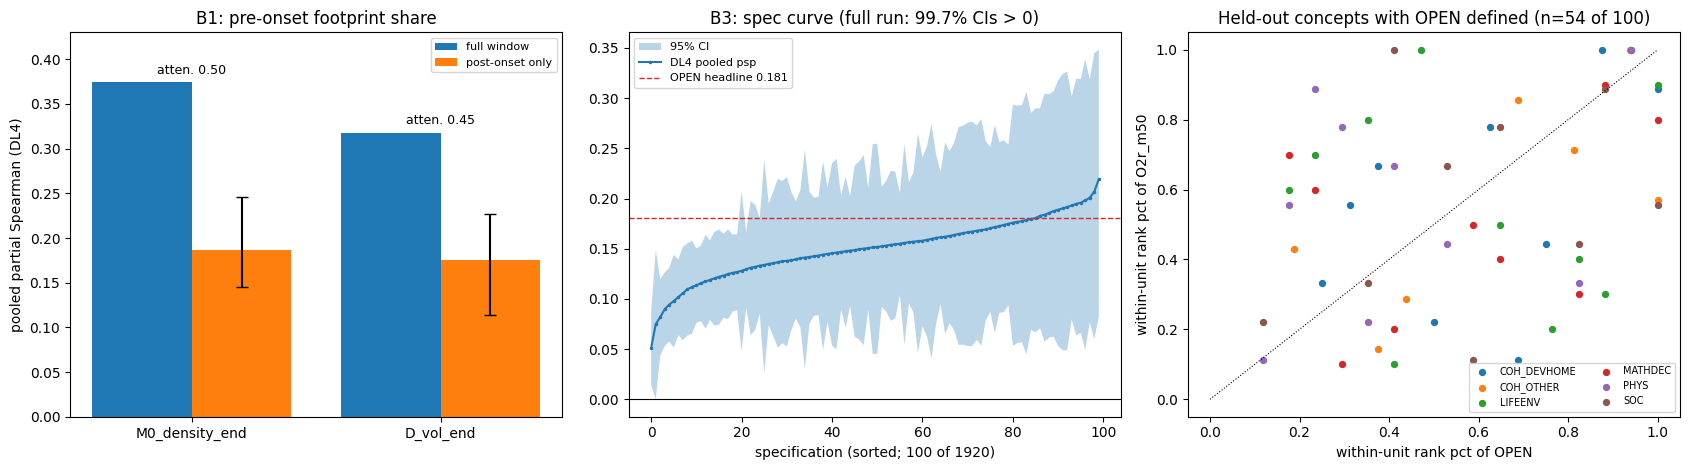

metadata_unit
COH_DEVHOME    0.450
COH_OTHER      0.643
LIFEENV       -0.139
MATHDEC        0.479
PHYS           0.283
SOC            0.300


In [14]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

# 1) B1 full vs post-onset psp (DL4, O2r_m50) with post-onset bootstrap CI
labs, full_v, post_v, lo, hi = [], [], [], [], []
for tag, name in (("M0", "M0_density_end"), ("Dvol", "D_vol_end")):
    s = f"B1_{tag}_O2r_m50"
    labs.append(name); full_v.append(m[f"{s}_psp_full"]); post_v.append(m[f"{s}_psp_post"])
    lo.append(m[f"{s}_psp_post_ci_lo"]); hi.append(m[f"{s}_psp_post_ci_hi"])
x = np.arange(len(labs))
ax[0].bar(x - 0.2, full_v, 0.4, label="full window")
ax[0].bar(x + 0.2, post_v, 0.4, label="post-onset only",
          yerr=[np.array(post_v) - lo, np.array(hi) - post_v], capsize=4)
for i in range(len(labs)):
    ax[0].text(i, max(full_v[i], hi[i]) + 0.01, f"atten. {1 - post_v[i] / full_v[i]:.2f}", ha="center", fontsize=9)
ax[0].set_ylim(0, max(full_v + hi) * 1.15); ax[0].set_xticks(x, labs); ax[0].set_ylabel("pooled partial Spearman (DL4)")
ax[0].set_title("B1: pre-onset footprint share"); ax[0].legend(fontsize=8)

# 2) spec curve over the demo slice of specifications
S = pd.DataFrame([e for d in out["datasets"] if d["dataset"] == "spec_curve" for e in d["examples"]])
S = S.sort_values("eval_DL4_est").reset_index(drop=True)
ci = S.predict_DL4_pooled_psp.str.extract(r"\[(\S+), (\S+)\]").astype(float)
ax[1].fill_between(S.index, ci[0], ci[1], alpha=0.3, label="95% CI")
ax[1].plot(S.index, S.eval_DL4_est, ".-", ms=3, label="DL4 pooled psp")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].axhline(m["OPEN_O2r_m50_DL4_psp"], color="C3", ls="--", lw=1, label=f"OPEN headline {m['OPEN_O2r_m50_DL4_psp']:.3f}")
ax[1].set_xlabel(f"specification (sorted; {len(S)} of {data['table_full_sizes']['spec_curve_specs']})")
ax[1].set_title(f"B3: spec curve (full run: {m['spec_DL4_share_ci_gt0']:.1%} CIs > 0)"); ax[1].legend(fontsize=8)

# 3) concepts: within-unit rank of OPEN vs rank of the outcome
C = pd.DataFrame([e for d in out["datasets"] if d["dataset"] == "open_heldout_concepts" for e in d["examples"]])
n_all = len(C)   # OPEN is undefined (NA) for some concepts; those are dropped from the scatter
C = C.dropna(subset=["eval_rank_pct_OPEN", "eval_rank_pct_O2r_m50"])
for u, g in C.groupby("metadata_unit"):
    ax[2].scatter(g.eval_rank_pct_OPEN, g.eval_rank_pct_O2r_m50, s=18, label=u)
ax[2].plot([0, 1], [0, 1], "k:", lw=0.8)
ax[2].set_xlabel("within-unit rank pct of OPEN"); ax[2].set_ylabel("within-unit rank pct of O2r_m50")
ax[2].set_title(f"Held-out concepts with OPEN defined (n={len(C)} of {n_all})"); ax[2].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

print(C.groupby("metadata_unit")[["eval_rank_pct_OPEN", "eval_rank_pct_O2r_m50"]]
      .apply(lambda g: g.corr(method="spearman").iloc[0, 1]).rename("demo Spearman(OPEN, O2r_m50)").round(3).to_string())